The Trust Region Method is one of the most robust and reliable optimization techniques out there — used in everything from numerical optimization solvers (like SciPy’s 'trust-constr') to machine learning and engineering problems. The trust region method restricts the step size to a region where the
quadratic approximation of the cost function is valid, ensuring stability

In [1]:
from scipy.optimize import minimize
import numpy as np

# Rosenbrock function
def rosen(x):
    return sum(100.0*(x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Initial guess
x0 = np.array([1.3, 0.7])

# Trust region method
res = minimize(rosen, x0, method='trust-constr', options={'verbose': 1})

print("\nSolution:")
print(res.x)

`xtol` termination condition is satisfied.
Number of iterations: 37, function evaluations: 99, CG iterations: 53, optimality: 1.43e-07, constraint violation: 0.00e+00, execution time: 0.13 s.

Solution:
[0.99999547 0.99999093]


# Barrier Method
The barrier method solves constrained optimization by penalizing constraint violations with a logarithmic barrier, keeping updates within the feasible region. This is another elegant strategy for solving constrained optimization problems, particularly inequality constraints. It's kind of the sibling to the Penalty Method, but with an interior-point twist.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Objective and barrier function
def f(x): return x[0]**2
def barrier(x): return -np.log(x[0] - 1)
def phi(x, t): return t * f(x) + barrier(x)

# Barrier method loop
x_init = np.array([1.5])
t = 1
mu = 10
epsilon = 1e-5

x = x_init
history = []

while True:
    res = minimize(lambda x: phi(x, t), x, method='BFGS')
    x = res.x
    history.append(x[0])
    if 1/t < epsilon:
        break
    t *= mu

print(f"Optimal x ≈ {x[0]:.5f}")

Optimal x ≈ -1022.50006


C:\Users\delll\AppData\Local\Temp\ipykernel_10644\3867968314.py:7: RuntimeWarning: invalid value encountered in log
  def barrier(x): return -np.log(x[0] - 1)
C:\Users\delll\AppData\Local\Temp\ipykernel_10644\3867968314.py:7: RuntimeWarning: invalid value encountered in log
  def barrier(x): return -np.log(x[0] - 1)
C:\Users\delll\AppData\Local\Temp\ipykernel_10644\3867968314.py:7: RuntimeWarning: invalid value encountered in log
  def barrier(x): return -np.log(x[0] - 1)


# Simulated Annealing
 a probabilistic global optimization technique inspired by metallurgy (specifically, the annealing process of slowly cooling metal). It's especially useful when dealing with non-convex, multi-modal optimization problems where traditional methods get stuck in local minima.

Best x found: -1.3053 with f(x) = -7.9458


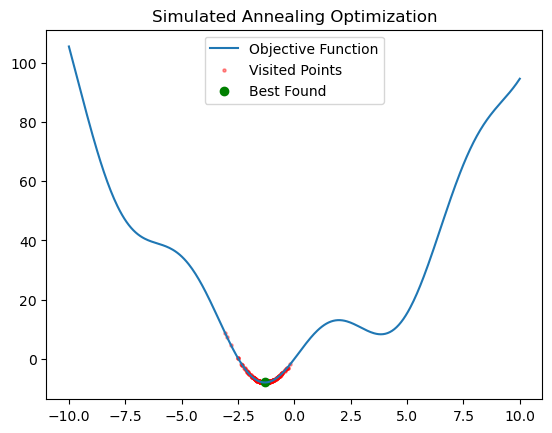

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Objective function
def f(x):
    return x**2 + 10 * np.sin(x)

# Simulated Annealing
np.random.seed(42)
x = np.random.uniform(-10, 10)  # Initial solution
T = 10                          # Initial temperature
T_min = 1e-5
alpha = 0.99                   # Cooling rate

best_x = x
best_f = f(x)

history = [x]

while T > T_min:
    x_new = x + np.random.uniform(-1, 1)  # Neighbor
    delta = f(x_new) - f(x)

    if delta < 0 or np.random.rand() < np.exp(-delta / T):
        x = x_new
        if f(x) < best_f:
            best_x = x
            best_f = f(x)
    T *= alpha
    history.append(x)

print(f"Best x found: {best_x:.4f} with f(x) = {best_f:.4f}")

# Plotting the progress
x_vals = np.linspace(-10, 10, 400)
plt.plot(x_vals, f(x_vals), label='Objective Function')
plt.scatter(history, [f(xi) for xi in history], color='red', s=5, alpha=0.4, label='Visited Points')
plt.scatter(best_x, best_f, color='green', label='Best Found')
plt.title("Simulated Annealing Optimization")
plt.legend()
plt.show()